### Import dependencies

In [1]:
#import gwpy as gw
import oreonspy as op
import numpy as np
import matplotlib.pyplot as plt
import oreonspy.utils as ut

import os

In [2]:
op.__version__

'4.4.2'

In [ ]:
# LASER
E_in_avg = 1  #
lambd = 1064e-9  # m
#k = 2.*np.pi / lambd

In [4]:
# Creating of the name list of the files in the folder tests/optical_cavities_testset
file_names = [file_name for file_name in os.listdir("../../tests/optical_cavities_testset") if file_name.endswith('.xml')]

print(f"Nomi dei file trovati: {file_names}")

Nomi dei file trovati: ['cavity_14397bf2-8fe3-5c85-811d-053248fff88c.xml', 'cavity_1a61c87f-5715-5ad7-b68d-291ce4be6cfb.xml', 'cavity_7d9a4874-1582-586f-899b-814c287a71df.xml', 'cavity_d04053d2-4a5e-5b90-a32e-381f745a3cb4.xml', 'cavity_44775a16-eade-5508-8790-40517bc6c5cb.xml', 'cavity_2cabab7b-02e7-5ccc-9f53-12299da99724.xml', 'cavity_ee83efce-96ca-54e4-9016-1496c05c3a46.xml', 'cavity_1b834b5a-a64d-521b-82c6-a09751fc4817.xml', 'cavity_c04207c3-fc1d-5a10-87fb-adb6b33e7aa4.xml', 'cavity_9091728a-dfbc-504b-abc7-990f30cfde82.xml', 'cavity_4469917c-b658-568e-9f45-5155da41ee3a.xml', 'cavity_c0ce476c-359b-5592-bdaa-8ba1797af58d.xml', 'cavity_4ca5ed57-c6d0-54ae-8b16-903b27cac8c8.xml', 'cavity_cbd7f5db-a267-57eb-8a47-4ecf81e9e2c3.xml', 'cavity_0c4b9c47-5b22-5678-9107-511887fa03d8.xml', 'cavity_142ab657-b670-55ad-9420-1838a153873b.xml', 'cavity_87ea86c6-0db4-578b-ba3e-fdc56a3749a6.xml', 'cavity_faab30cb-7f62-543b-9bf5-039f59622142.xml', 'cavity_f34546f2-cb22-540f-88a9-dbd0033e1ecb.xml', 'cavity

In [5]:
# Extracting the list of file paths
file_paths = [os.path.join("../tests/optical_cavities_testset", file_name) for file_name in file_names]

print(f"File paths trovati: {file_paths}")

File paths trovati: ['../tests/optical_cavities_testset/cavity_14397bf2-8fe3-5c85-811d-053248fff88c.xml', '../tests/optical_cavities_testset/cavity_1a61c87f-5715-5ad7-b68d-291ce4be6cfb.xml', '../tests/optical_cavities_testset/cavity_7d9a4874-1582-586f-899b-814c287a71df.xml', '../tests/optical_cavities_testset/cavity_d04053d2-4a5e-5b90-a32e-381f745a3cb4.xml', '../tests/optical_cavities_testset/cavity_44775a16-eade-5508-8790-40517bc6c5cb.xml', '../tests/optical_cavities_testset/cavity_2cabab7b-02e7-5ccc-9f53-12299da99724.xml', '../tests/optical_cavities_testset/cavity_ee83efce-96ca-54e4-9016-1496c05c3a46.xml', '../tests/optical_cavities_testset/cavity_1b834b5a-a64d-521b-82c6-a09751fc4817.xml', '../tests/optical_cavities_testset/cavity_c04207c3-fc1d-5a10-87fb-adb6b33e7aa4.xml', '../tests/optical_cavities_testset/cavity_9091728a-dfbc-504b-abc7-990f30cfde82.xml', '../tests/optical_cavities_testset/cavity_4469917c-b658-568e-9f45-5155da41ee3a.xml', '../tests/optical_cavities_testset/cavity_c0

In [6]:
# Extracting the list of the UUIDs from the file names
UUIDS = []
for file_name in file_names:
    uuid = file_name.split('_')[1].split('.')[0]
    UUIDS.append(uuid)
print(len(UUIDS))

99


In [7]:
import xml.etree.ElementTree as ET

# Path of the XML file
file_path = '../../tests/optical_cavities.xml'

# Parsing of the XML file
tree = ET.parse(file_path)
root = tree.getroot()

# List to store UUIDs of the cavities to load
UUIDS_to_load = []

# Extracting the wanted UUIDs from the XML file
for cavity in root.findall('Cavity'):
    uuid_element = cavity.find('UUID')
    if uuid_element is not None:
        UUIDS_to_load.append(uuid_element.text)

# Printing the UUIDs to load
print(f"All UUIDs found: {len(UUIDS_to_load)}")

All UUIDs found: 99


In [8]:
# Filter and parse cavities with UUIDs present in UUIDS
filtered_cavities = []
filtered_UUIDS = []

for file_path in file_paths:
    cavity = op.Cavity()
    uuid = file_name.split('_')[1].split('.')[0]
    if uuid in UUIDS_to_load:
        filtered_UUIDS.append(uuid)
        #print(uuid)
        #print(f"Parsing cavity: {file_name}")
        cavity.xml_load(file_path)
        # print(cavity)
        #print(f"Finesse: {cavity.Finesse()}", f"Length: {cavity.__L__}")
        filtered_cavities.append(cavity)    

# Select one cavity every five
selected_cavities = filtered_cavities[::5]
selected_UUIDS = filtered_UUIDS[::5]
print(f"Selected {len(selected_cavities)} cavities from the filtered list.")

Selected 20 cavities from the filtered list.


In [9]:
print(selected_cavities[0])
print(selected_UUIDS[0])

b71f3c26-1518-51fc-a859-fed711d81b8e


In [10]:
cavity = selected_cavities[0]

In [11]:
cavity.print_params()
v_cr = ut.critical_velocity(cavity, wavelength=ut.lambd, L=cavity.params.cavity_length, Finesse=cavity.Finesse())
velocity_factor = 5
f_calc = ut.optimal_sampling_frequency(cavity=cavity, critical_velocity_factor=velocity_factor)
print(f"Critical velocity: {v_cr}")
print(f"Optimal sampling frequency: {f_calc}")

t_a: 0.001
r_a: 0.99
r_b: 0.999
cavity_length: 3000.0
Critical velocity: 1.0332935163643289e-06
Optimal sampling frequency: 16475.010834648077


In [21]:
# LASER
E_in_avg = 1.+0.j  #

def generate_cavity_evolution(cavity, z_evolution, E_evolution, num_points, time_steps, title=None):
    results = np.zeros(num_points, dtype=np.complex128)

    z_evolution = np.append(z_evolution, z_evolution[-1])
    
    for t in range(num_points):
        d_zeta = z_evolution[t+1]-z_evolution[t]
        results[t], _ = cavity.sim_step(E_evolution[t], output_mirror_displacement=d_zeta, )
    
    s = np.abs(results)**2
    ph = np.angle(results)
    pdh = ut.V_pdh(0., E_evolution, results)
    
    print(f"Results for v = {velocity_factor} v_cr and f_calc = {f_calc} Hz:")
    #print(results)

    simple_plot = False
    if simple_plot is False:
        ut.plot_cavity_evolution(output_mirror_displacements=z_evolution, input_electric_field=E_evolution, intracav_electric_field=results, pdh=pdh, file_name=title)
    else:
        plt.plot(time_steps, s)
        plt.plot(time_steps, ph)
        plt.plot(time_steps, pdh)
        plt.xlabel('Time (s)')
        plt.ylabel('Cavity Evolution')
        plt.title(f'Cavity Evolution for v = {velocity_factor} v_cr and f_calc = {f_calc} Hz')
        plt.show()
    return s, ph, pdh

wave_number: 5905249.348852994
k2j: -11810498.697705988j
requested_sampling_frequency: 16655.136555555557
initial_input_electric_field: (1+0j)
sampling_frequency: 16655.136555555557
num_roundtrips: 3
Theta: 6.004153713566736e-05
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 1.0
Results for v = 5 v_cr and f_calc = 16655.136555555557 Hz:


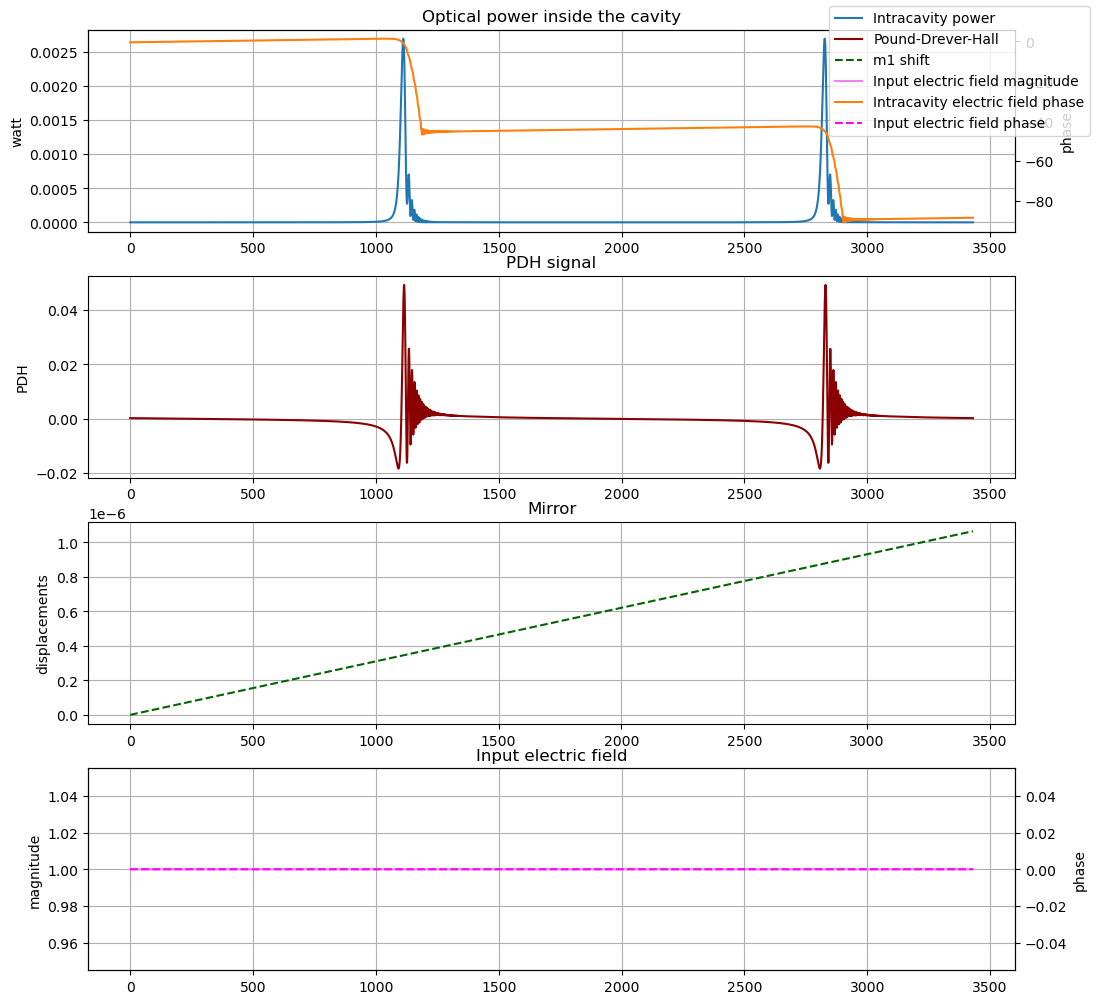

In [28]:
# Define velocities and f_calc range
# velocity_factors = np.array([0.1, 1, 2, 5, 10])
# frequency_factors = np.array([1, 3, 10])

cavity.simulation(lambd, f_calc, E_in_avg)
cavity.print_sim_params()
f_calc = cavity.sim_params.sampling_frequency

num_points, time_steps = ut.generate_time_points_for_constant_velocity(velocity=v_cr*velocity_factor, f_calc = f_calc)
E_ev = np.ones(num_points)

z_ev = np.linspace(0., ut.lambd, num_points) 

s, ph, pdh = generate_cavity_evolution(cavity, z_ev, E_ev, num_points, time_steps)




### Simulatng with low frequency

In [29]:
# Filter and parse cavities with UUIDs present in UUIDS
filtered_cavities1 = []
filtered_UUIDS = []

for file_path in file_paths:
    cavity1 = op.Cavity()
    uuid = file_name.split('_')[1].split('.')[0]
    if uuid in UUIDS_to_load:
        filtered_UUIDS.append(uuid)
        #print(uuid)
        #print(f"Parsing cavity: {file_name}")
        cavity1.xml_load(file_path)
        # print(cavity)
        #print(f"Finesse: {cavity.Finesse()}", f"Length: {cavity.__L__}")
        filtered_cavities1.append(cavity)    

# Select one cavity every five
selected_cavities = filtered_cavities1[::5]
selected_UUIDS = filtered_UUIDS[::5]
print(f"Selected {len(selected_cavities)} cavities from the filtered list.")

Selected 20 cavities from the filtered list.


wave_number: 5905249.348852994
k2j: -11810498.697705988j
requested_sampling_frequency: 2000.0
initial_input_electric_field: (1+0j)
sampling_frequency: 1998.6163866666666
num_roundtrips: 25
Theta: 0.0005003461427972281
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.9993081933333333
412
Results for v = 5 v_cr and f_calc = 16655.136555555557 Hz:


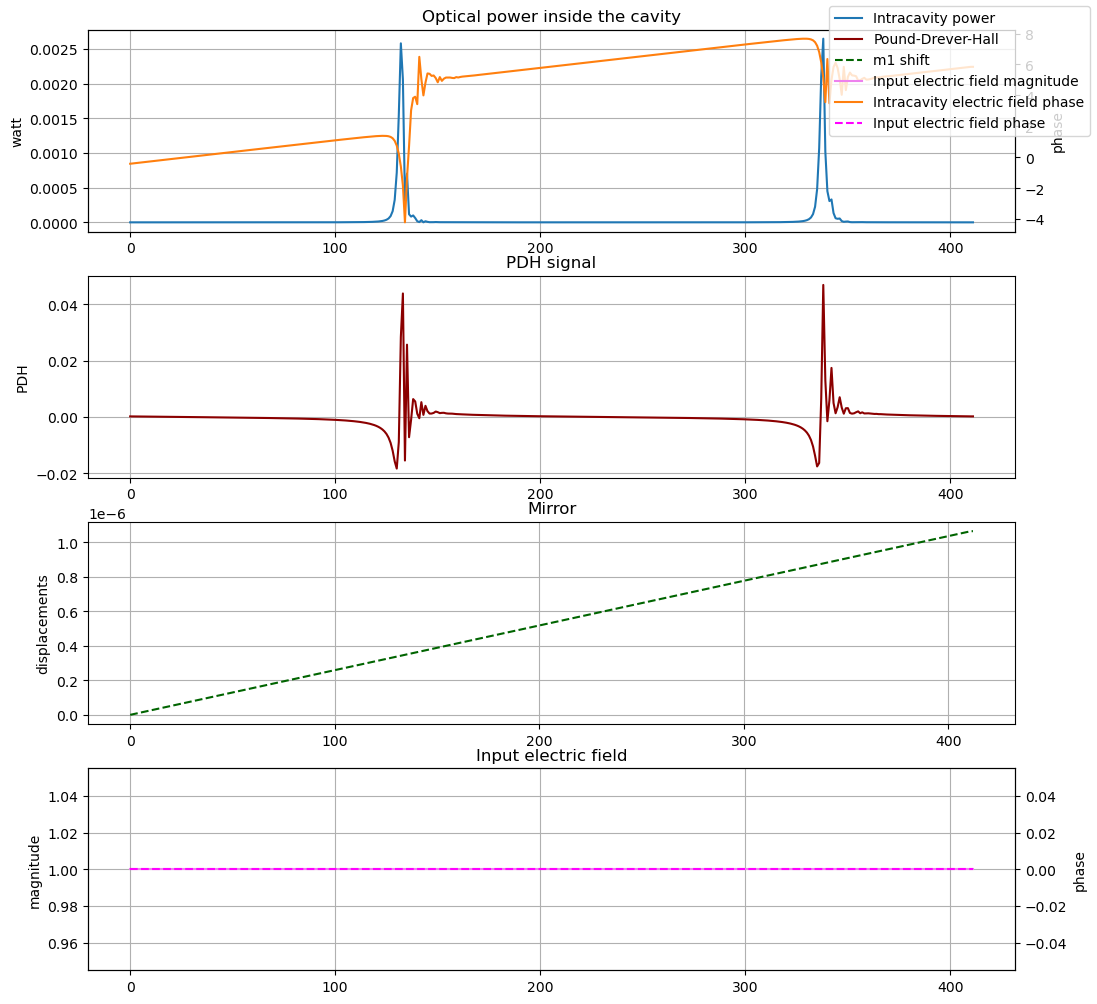

In [59]:
f_low = 2e3

cavity1 = selected_cavities[0]

cavity1.simulation(lambd, f_low, E_in_avg)
cavity1.print_sim_params()
f_low = cavity1.sim_params.sampling_frequency

num_points, time_steps_low = ut.generate_time_points_for_constant_velocity(velocity=v_cr*velocity_factor, f_calc = f_low)
print(num_points)

E_ev = np.ones(num_points)

z_ev_low = np.linspace(0., ut.lambd, num_points) 

s_low, ph_low, pdh_low = generate_cavity_evolution(cavity1, z_ev_low, E_ev, num_points, time_steps_low)



In [65]:
d_t = time_steps[1] - time_steps[0]
print(d_t)

print(d_t)

6.004181323504565e-05
6.004181323504565e-05


In [66]:
d_t_low = time_steps_low[1] - time_steps_low[0]
print(d_t_low)

# This corrections is needed to plot the low sampled signal overlapped to the high sampled one. The reason is still under investigation.
t_correction = d_t_low-d_t
print(t_correction)

0.000501078879309505
0.0004410370660744594


### Resampling of the time series and plotting

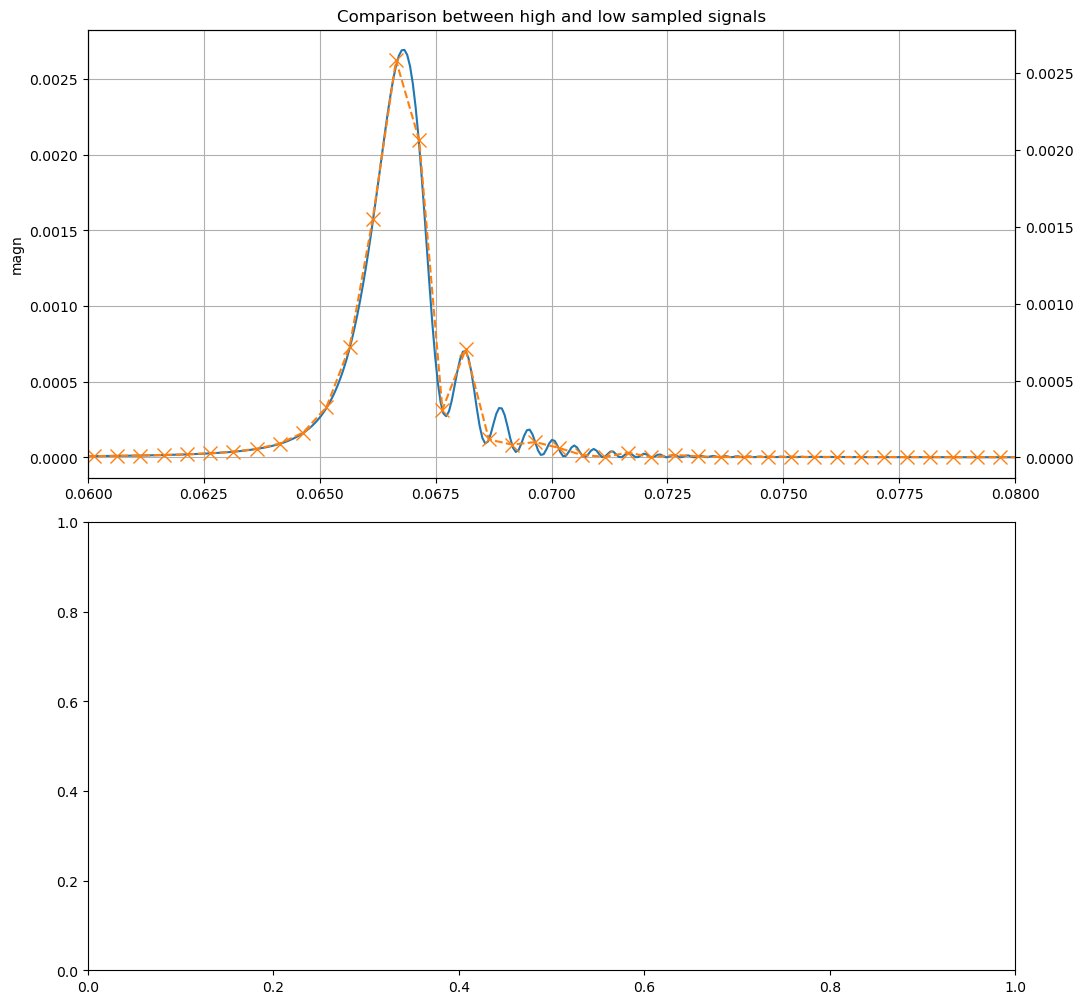

In [68]:
#from gwpy.timeseries import TimeSeries

#s_high = TimeSeries(s, sample_rate=f_calc)
#s_low= TimeSeries(s_low, sample_rate=f_low)
#s_high_resampled = s_high.resample(rate= f_low)

#print("Points for high frequency: {0}". format({len(s_high)}))
#print('Points for low frequency: {0}'.format({len(s_low)}))
#print("Points for resampled series:{0}".format(len(s_high_resampled)))

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
fig.tight_layout()
ax[0].plot(time_steps+d_t, s, label="High sampled")
ax[0].grid()
ax[0].set_ylabel("magn")
ax[0].title.set_text("Comparison between high and low sampled signals")
ax[0].set_xlim(0.06,0.08)
ax2 = ax[0].twinx()

ax2.plot(time_steps_low+d_t_low, s_low, label="low_sampled", color='tab:orange', linestyle='--', marker='x', markersize=10)
ax2.tick_params(axis='y')

plt.show()

## Normal and slow simulation grid check

In [34]:
i = -1
print(time_steps[i])
print(time_steps_low[i])

0.20594341939620658
0.20594341939620658


In [35]:
i = 4
print(z_ev[i])
print(z_ev_low[i])

1.2408163265306125e-09
2.07609756097561e-08


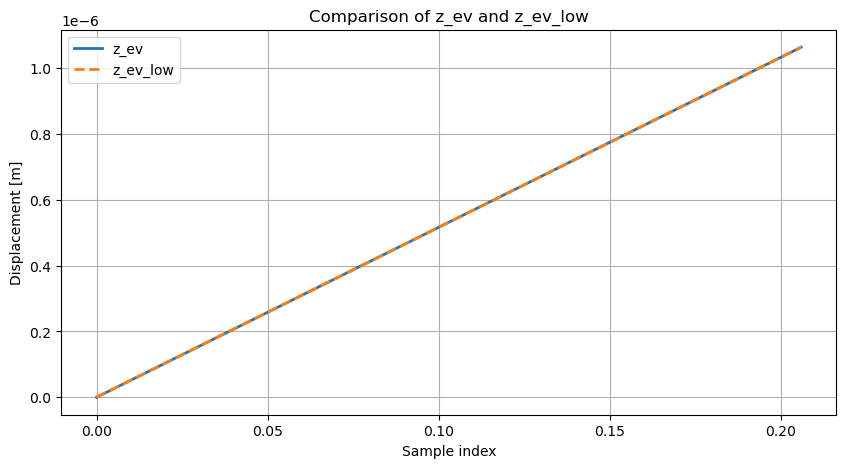

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(time_steps, z_ev, label="z_ev", linewidth=2)
plt.plot(time_steps_low, z_ev_low, label="z_ev_low", linewidth=2, linestyle="--")
plt.xlabel("Sample index")
plt.ylabel("Displacement [m]")
plt.title("Comparison of z_ev and z_ev_low")
plt.grid(True)
plt.legend()
plt.show()